# Cell 1 — Imports and path setup

In [11]:

import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from src.data_loader import get_train_val_test
from src.preprocess import apply_cleaning


# Cell 2 — Label map

In [12]:
LABEL_MAP = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}


# Cell 3 — Load data

In [13]:
X_train, X_val, X_test, y_train, y_val, y_test = get_train_val_test(
    "../data/raw/train.csv",
    "../data/raw/test.csv"
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

print("Unique train labels:", sorted(pd.Series(y_train).unique()))
print("Unique val labels:", sorted(pd.Series(y_val).unique()))
print("Unique test labels:", sorted(pd.Series(y_test).unique()))


Train size: 96000
Validation size: 24000
Test size: 7600
Unique train labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Unique val labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Unique test labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


# Cell 4 — Apply preprocessing

In [14]:

X_train_clean = apply_cleaning(X_train)
X_val_clean = apply_cleaning(X_val)
X_test_clean = apply_cleaning(X_test)  


# Cell 5 — Load best model

In [15]:
MODEL_PATH = "../models/best_model.pkl"
model = joblib.load(MODEL_PATH)

print("Loaded model from:", MODEL_PATH)
model


Loaded model from: ../models/best_model.pkl


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


# Cell 6 — Predict and evaluate

In [16]:
y_pred = model.predict(X_test_clean)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", acc)
print("Macro F1:", macro_f1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.9017105263157895
Macro F1: 0.901452259573442

Classification Report:

              precision    recall  f1-score   support

           1       0.92      0.89      0.91      1900
           2       0.94      0.98      0.96      1900
           3       0.87      0.86      0.87      1900
           4       0.87      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



# Cell 7 — Save metrics CSV

In [17]:
os.makedirs("../reports/metrics", exist_ok=True)

metrics_df = pd.DataFrame([{
    "model_path": "../models/best_model.pkl",
    "accuracy": acc,
    "macro_f1": macro_f1
}])

metrics_df.to_csv("../reports/metrics/week6_best_model_metrics.csv", index=False)
metrics_df


,model_path,accuracy,macro_f1
0,../models/best_model.pkl,0.901711,0.901452


# Cell 8 — Confusion matrix

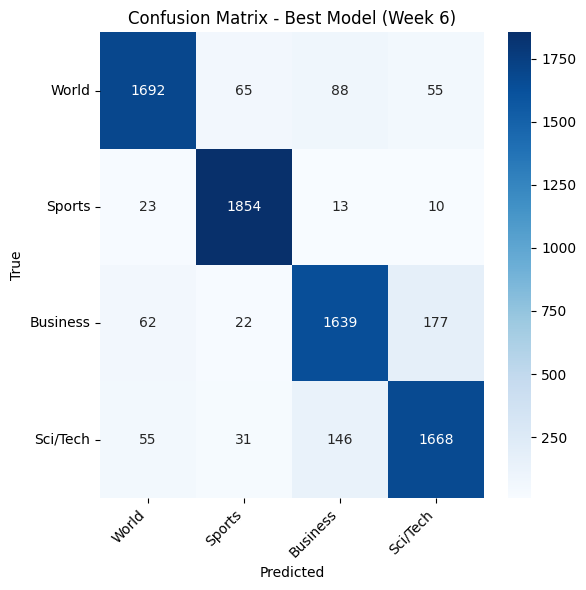

In [18]:
cm = confusion_matrix(y_test, y_pred)

classes = sorted(LABEL_MAP.keys())
tick_labels = [LABEL_MAP[c] for c in classes]

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(classes)) + 0.5, tick_labels, rotation=45, ha="right")
plt.yticks(np.arange(len(classes)) + 0.5, tick_labels, rotation=0)
plt.title("Confusion Matrix - Best Model (Week 6)")
plt.tight_layout()

os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/week6_confusion_matrix_best_model.png", bbox_inches="tight")
plt.show()


# Cell 9 — Export misclassified samples

In [19]:
mis_idx = np.where(pd.Series(y_test).to_numpy() != y_pred)[0]

rows = []
for i in mis_idx[:50]:
    true_id = int(y_test.iloc[i]) if hasattr(y_test, "iloc") else int(y_test[i])
    pred_id = int(y_pred[i])

    rows.append({
        "true_id": true_id,
        "pred_id": pred_id,
        "true_label": LABEL_MAP.get(true_id, str(true_id)),
        "pred_label": LABEL_MAP.get(pred_id, str(pred_id)),
        "text_snippet": str(X_test.iloc[i])[:250]
    })

misclassified_df = pd.DataFrame(rows)
misclassified_df.to_csv("../reports/metrics/week6_misclassified_samples.csv", index=False)

misclassified_df.head(10)


,true_id,pred_id,true_label,pred_label,text_snippet
0,4,2,Sci/Tech,Sports,Prediction Unit Helps Forecast Wildfires (AP) ...
1,4,3,Sci/Tech,Business,Teenage T. rex's monster growth Tyrannosaurus ...
2,4,3,Sci/Tech,Business,Rivals Try to Turn Tables on Charles Schwab By...
3,1,3,World,Business,Venezuela Prepares for Chavez Recall Vote Supp...
4,4,2,Sci/Tech,Sports,Promoting a Shared Vision As Michael Kaleko ke...
5,1,3,World,Business,India's Tata expands regional footprint via Na...
6,1,2,World,Sports,Live: Olympics day four Richard Faulds and Ste...
7,3,4,Business,Sci/Tech,Intel to delay product aimed for high-definiti...
8,1,2,World,Sports,"U.S. Misses Cut in Olympic 100 Free ATHENS, Gr..."
9,1,3,World,Business,Stocks Climb on Drop in Consumer Prices NEW YO...


# Cell 10 — Final output check

In [20]:
print("Saved files:")
print("- ../reports/metrics/week6_best_model_metrics.csv")
print("- ../reports/figures/week6_confusion_matrix_best_model.png")
print("- ../reports/metrics/week6_misclassified_samples.csv")


Saved files:
- ../reports/metrics/week6_best_model_metrics.csv
- ../reports/figures/week6_confusion_matrix_best_model.png
- ../reports/metrics/week6_misclassified_samples.csv
